In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
DATA_ROOT = "/kaggle/input/nih-chest-xrays"

In [3]:
for root, dirs, files in os.walk(DATA_ROOT):
    for f in files:
        if f.endswith(".csv"):
            print(os.path.join(root, f))

In [4]:
df = pd.read_csv(f"/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv")

df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [5]:
print(df.shape)

(112120, 12)


In [6]:
df["Target"] = df["Finding Labels"].apply(
    lambda labels: 1 if "Pneumonia" in str(labels).split("|") else 0
)

print(df["Target"].value_counts())

Target
0    110689
1      1431
Name: count, dtype: int64


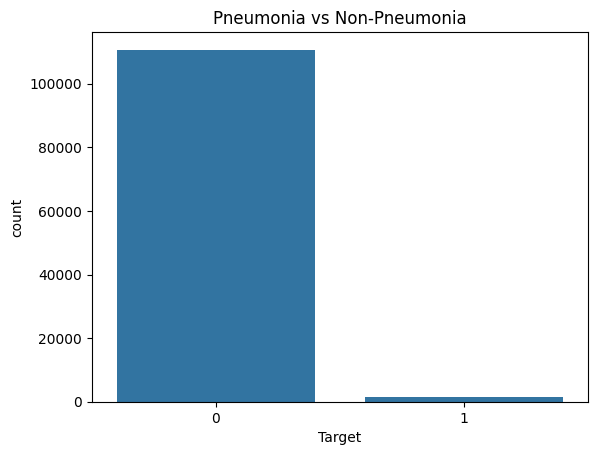

In [7]:
sns.countplot(x="Target", data=df)
plt.title("Pneumonia vs Non-Pneumonia")
plt.show()

In [8]:
pneumonia_df = df[df["Target"] == 1]

non_pneumonia_df = df[df["Target"] == 0].sample(
    n=len(pneumonia_df) * 2,
    random_state=42
)

df_balanced = pd.concat([pneumonia_df, non_pneumonia_df])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced["Target"].value_counts())

Target
0    2862
1    1431
Name: count, dtype: int64


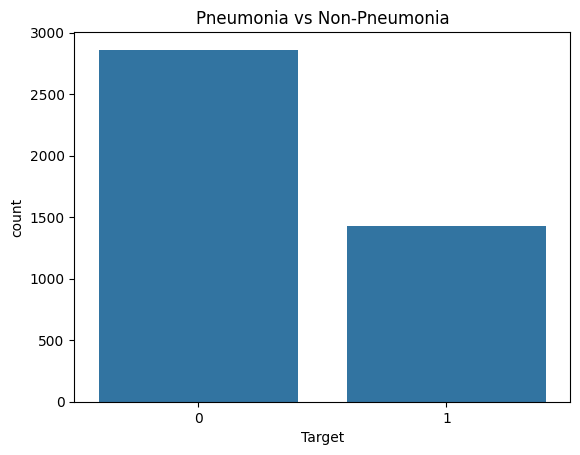

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Target", data=df_balanced)
plt.title("Pneumonia vs Non-Pneumonia")
plt.show()

In [10]:
DATA_ROOT = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"

In [11]:
import os

all_images = []

for root, dirs, files in os.walk(DATA_ROOT):
    for file in files:
        if file.endswith(".png"):
            all_images.append(os.path.join(root, file))

print("Total images found:", len(all_images))
print(all_images[:5])

Total images found: 112120
['/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006199_010.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004833_016.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00006260_000.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004911_010.png', '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_003/images/00004186_007.png']


In [12]:
image_path_map = {os.path.basename(x): x for x in all_images}

df_balanced["path"] = df_balanced["Image Index"].map(image_path_map)
df_balanced = df_balanced.dropna(subset=["path"]).reset_index(drop=True)

print(df_balanced.shape)
print(df_balanced["path"].isnull().sum())
df_balanced[["Image Index", "path"]].head()

(4293, 14)
0


,Image Index,path
0,00018472_001.png,/kaggle/input/datasets/organizations/nih-chest...
1,00000116_020.png,/kaggle/input/datasets/organizations/nih-chest...
2,00002003_002.png,/kaggle/input/datasets/organizations/nih-chest...
3,00016490_019.png,/kaggle/input/datasets/organizations/nih-chest...
4,00026050_010.png,/kaggle/input/datasets/organizations/nih-chest...


In [13]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_balanced,
    test_size=0.3,
    stratify=df_balanced["Target"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["Target"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (3005, 14)
Validation shape: (644, 14)
Test shape: (644, 14)


In [14]:
print("Train target distribution:")
print(train_df["Target"].value_counts())

print("\nValidation target distribution:")
print(val_df["Target"].value_counts())

print("\nTest target distribution:")
print(test_df["Target"].value_counts())

Train target distribution:
Target
0    2003
1    1002
Name: count, dtype: int64

Validation target distribution:
Target
0    429
1    215
Name: count, dtype: int64

Test target distribution:
Target
0    430
1    214
Name: count, dtype: int64


In [15]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [16]:
def clahe_enhancement(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(gray)
    img = cv2.cvtColor(cl, cv2.COLOR_GRAY2RGB)
    return img

In [17]:
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, "path"]
        label = self.dataframe.loc[idx, "Target"]

        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        image = clahe_enhancement(image)
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [18]:
train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset = ChestXrayDataset(val_df, transform=val_test_transform)
test_dataset = ChestXrayDataset(test_df, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train dataset size: 3005
Validation dataset size: 644
Test dataset size: 644
Train batches: 94
Validation batches: 21
Test batches: 21


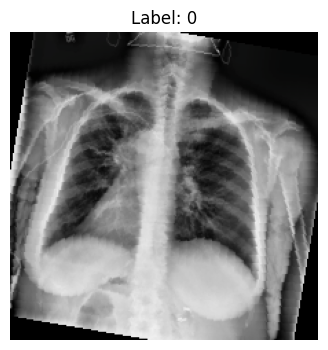

In [19]:
images, labels = next(iter(train_loader))

img = images[0].permute(1, 2, 0).numpy()
img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(f"Label: {int(labels[0].item())}")
plt.axis("off")
plt.show()

In [20]:
import os

os.makedirs("/kaggle/working/processed_data", exist_ok=True)

train_df.to_csv("/kaggle/working/processed_data/train.csv", index=False)
val_df.to_csv("/kaggle/working/processed_data/val.csv", index=False)
test_df.to_csv("/kaggle/working/processed_data/test.csv", index=False)

print("Saved successfully to /kaggle/working/processed_data")

Saved successfully to /kaggle/working/processed_data


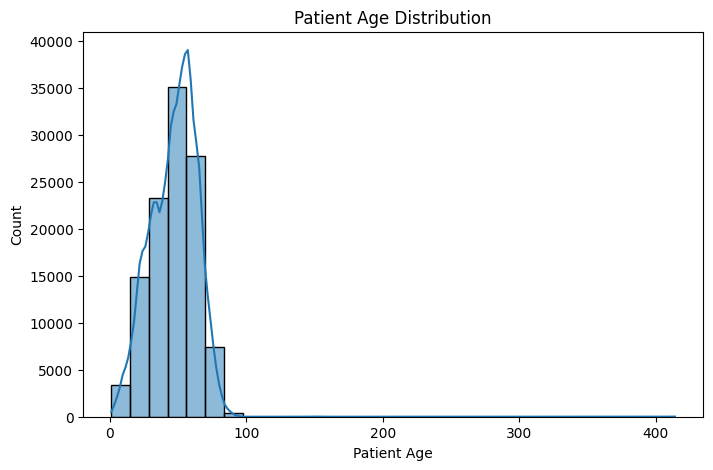

count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: Patient Age, dtype: float64


In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["Patient Age"], bins=30, kde=True)
plt.title("Patient Age Distribution")
plt.show()

print(df["Patient Age"].describe())

Patient Gender
M    63340
F    48780
Name: count, dtype: int64


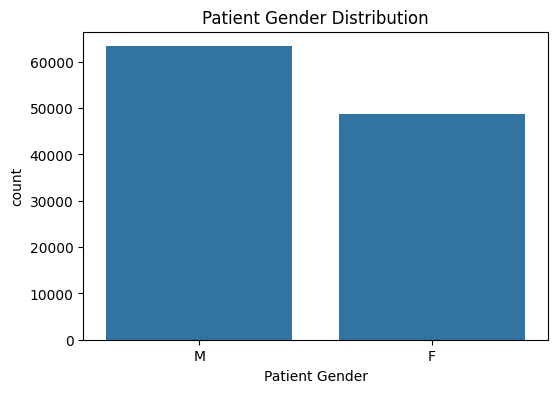

In [22]:
print(df["Patient Gender"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Patient Gender", data=df)
plt.title("Patient Gender Distribution")
plt.show()

View Position
PA    67310
AP    44810
Name: count, dtype: int64


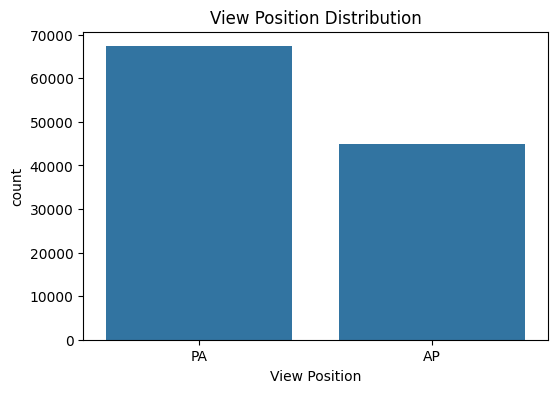

In [23]:
print(df["View Position"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="View Position", data=df)
plt.title("View Position Distribution")
plt.show()

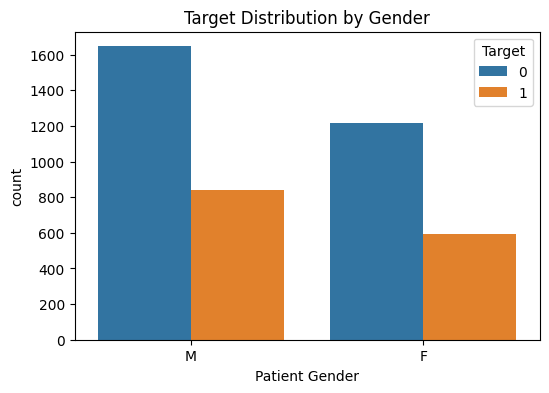

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Patient Gender", hue="Target", data=df_balanced)
plt.title("Target Distribution by Gender")
plt.show()

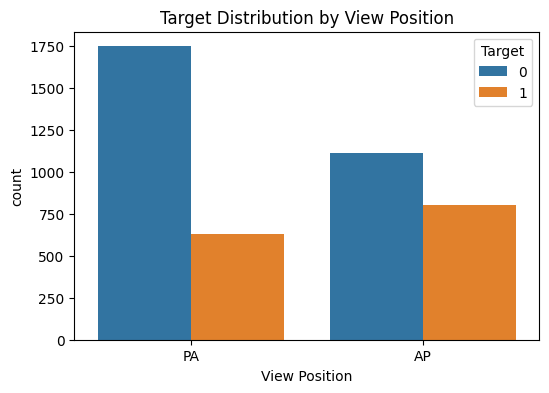

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="View Position", hue="Target", data=df_balanced)
plt.title("Target Distribution by View Position")
plt.show()

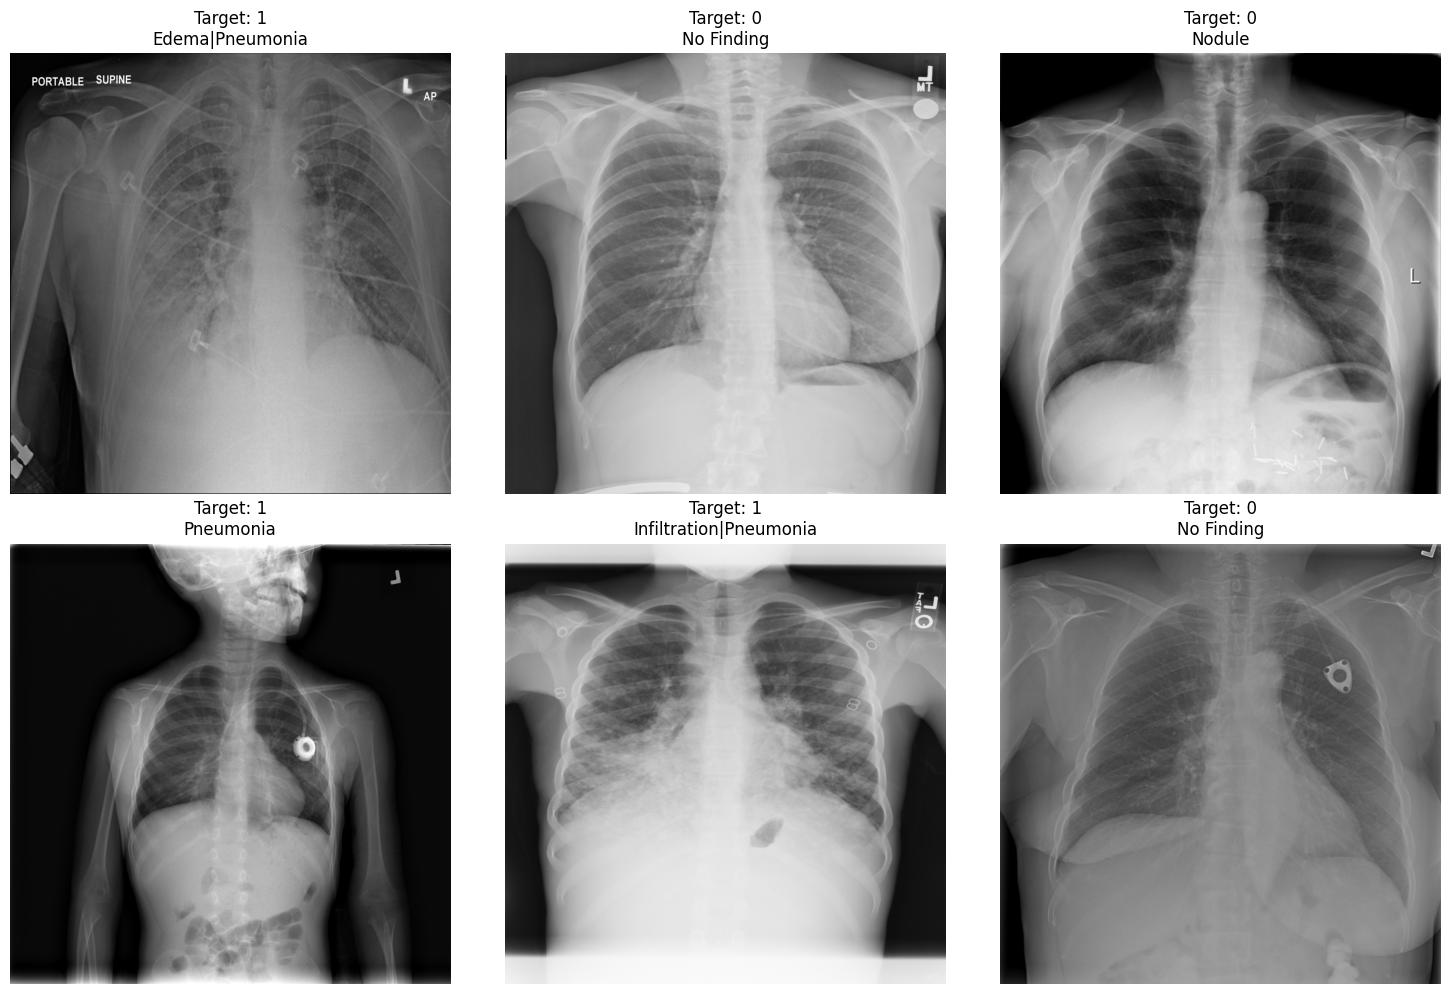

In [26]:
sample_rows = df_balanced.sample(6, random_state=42)

plt.figure(figsize=(15,10))
for i, (_, row) in enumerate(sample_rows.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(2,3,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(f'Target: {row["Target"]}\n{row["Finding Labels"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
print("EDA and preprocessing completed successfully.")
print("Final balanced dataset size:", df_balanced.shape)
print("Train set:", train_df.shape)
print("Validation set:", val_df.shape)
print("Test set:", test_df.shape)

EDA and preprocessing completed successfully.
Final balanced dataset size: (4293, 14)
Train set: (3005, 14)
Validation set: (644, 14)
Test set: (644, 14)


In [28]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix,classification_report)
import torch.nn.functional as F
import cv2
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
import torch
!pip install captum
from captum.attr import IntegratedGradients


In [29]:
class ImprovedDCNN(nn.Module):
    def __init__(self):
        super(ImprovedDCNN, self).__init__()

        self.features = nn.Sequential(

           
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   

           
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   

          
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), 

           
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  

            nn.AdaptiveAvgPool2d((1,1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [30]:
model = ImprovedDCNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [31]:
pos_weight = torch.tensor([1.5]).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [32]:

num_epochs =20
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/20 - Loss: 0.7970
Epoch 2/20 - Loss: 0.7863
Epoch 3/20 - Loss: 0.7848
Epoch 4/20 - Loss: 0.7827
Epoch 5/20 - Loss: 0.7778
Epoch 6/20 - Loss: 0.7794
Epoch 7/20 - Loss: 0.7763
Epoch 8/20 - Loss: 0.7740
Epoch 9/20 - Loss: 0.7765
Epoch 10/20 - Loss: 0.7718
Epoch 11/20 - Loss: 0.7763
Epoch 12/20 - Loss: 0.7697
Epoch 13/20 - Loss: 0.7667
Epoch 14/20 - Loss: 0.7679
Epoch 15/20 - Loss: 0.7644
Epoch 16/20 - Loss: 0.7687
Epoch 17/20 - Loss: 0.7669
Epoch 18/20 - Loss: 0.7689
Epoch 19/20 - Loss: 0.7608
Epoch 20/20 - Loss: 0.7597


In [33]:
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).int().cpu().numpy()
        all_predictions.extend(predictions.squeeze())
        all_labels.extend(labels.numpy())


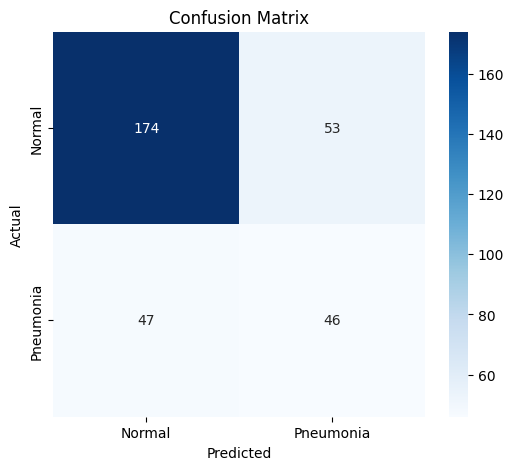

              precision    recall  f1-score   support

      Normal       0.79      0.77      0.78       227
   Pneumonia       0.46      0.49      0.48        93

    accuracy                           0.69       320
   macro avg       0.63      0.63      0.63       320
weighted avg       0.69      0.69      0.69       320



In [52]:

cm = confusion_matrix(all_labels, all_predictions)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Normal", "Pneumonia"],yticklabels=["Normal", "Pneumonia"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels,all_predictions,target_names=["Normal", "Pneumonia"]))

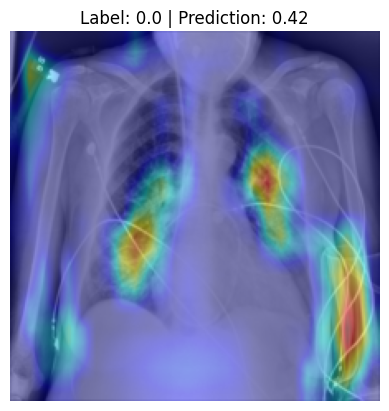

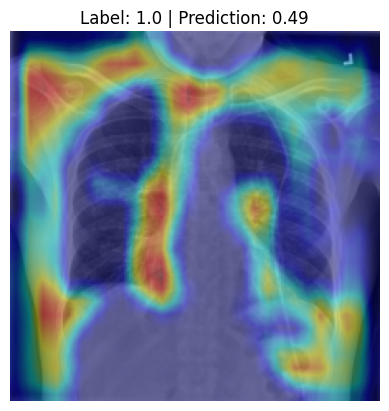

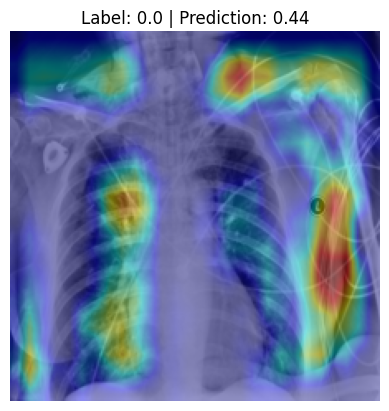

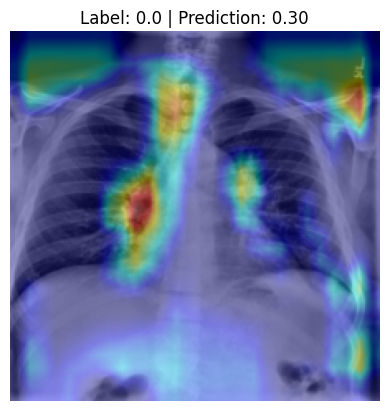

In [43]:
feature_maps = None
gradients = None

def forward_hook(module, input, output):
    global feature_maps
    feature_maps = output
def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]
target_layer = model.features[12]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def compute_gradcam(model, image):
    model.eval()
    output = model(image)
    model.zero_grad()
    output.backward()
    pooled_gradients = torch.mean(gradients, dim=[0,2,3])
    activations = feature_maps[0]
    for i in range(len(pooled_gradients)):
        activations[i] *= pooled_gradients[i]
    heatmap = torch.mean(activations, dim=0).cpu().detach().numpy()
    heatmap = np.maximum(heatmap, 0)
    heatmap = heatmap / (heatmap.max() + 1e-8)
    heatmap = cv2.resize(heatmap, (224,224))
    return heatmap
def display_gradcam(image_tensor, heatmap, label, prediction):
    image = image_tensor.cpu().numpy().transpose(1,2,0)
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    image = std * image + mean
    image = np.clip(image,0,1)
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap),
        cv2.COLORMAP_JET
    )
    heatmap_color = heatmap_color[...,::-1] / 255.0
    overlay = heatmap_color * 0.4 + image * 0.6
    overlay = np.clip(overlay,0,1)
    plt.imshow(overlay)
    plt.title(f"Label: {label} | Prediction: {prediction:.2f}")
    plt.axis("off")
    plt.show()
images, labels = next(iter(val_loader))
for i in range(4):
    image = images[i].unsqueeze(0).to(device)
    heatmap = compute_gradcam(model, image)
    prediction = torch.sigmoid(model(image)).item()
    display_gradcam(images[i], heatmap, labels[i].item(), prediction)

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.4831376].


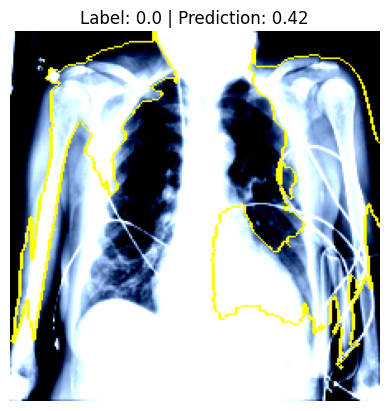

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..1.7859696].


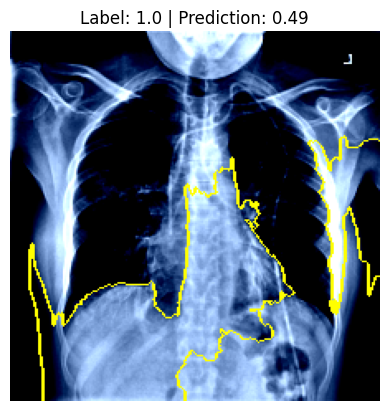

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4831376].


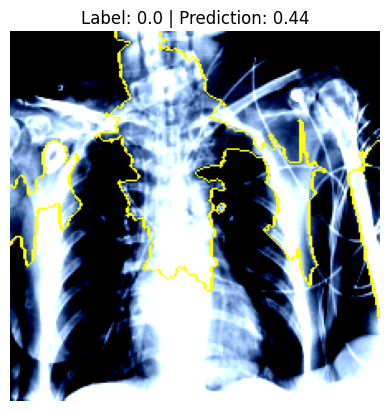

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4831376].


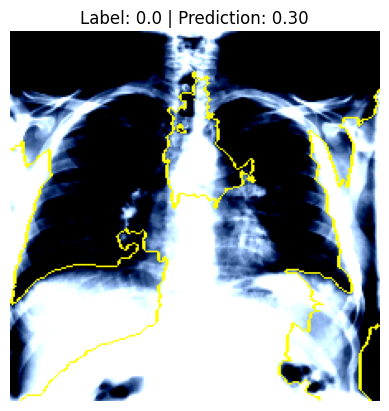

In [44]:
def lime_prediction(batch_images):
    batch_images = torch.tensor(batch_images)\
        .permute(0,3,1,2)\
        .float()\
        .to(device)
    outputs = model(batch_images)
    probabilities = torch.sigmoid(outputs)\
        .detach()\
        .cpu()\
        .numpy()
    return np.concatenate([1 - probabilities, probabilities],axis=1)
lime_explainer = lime_image.LimeImageExplainer()
def display_lime(image_tensor, explanation, label, prediction):
    highlighted_image, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    plt.imshow(mark_boundaries(highlighted_image, mask))
    plt.title(
        f"Label: {label} | Prediction: {prediction:.2f}"
    )
    plt.axis("off")
    plt.show()

images, labels = next(iter(val_loader))
for i in range(4):
    image_tensor = images[i]
    image_numpy = image_tensor.numpy().transpose(1,2,0)
    explanation = lime_explainer.explain_instance(
        image_numpy,
        lime_prediction,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    prediction = torch.sigmoid(
        model(image_tensor.unsqueeze(0).to(device))
    ).item()

    display_lime(image_tensor, explanation, labels[i].item(), prediction)

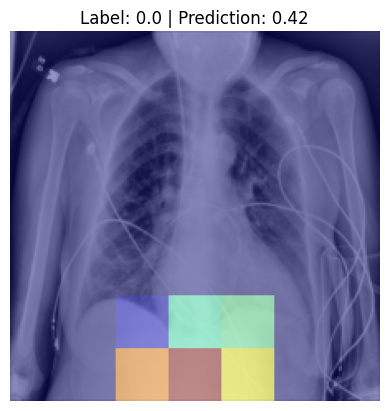

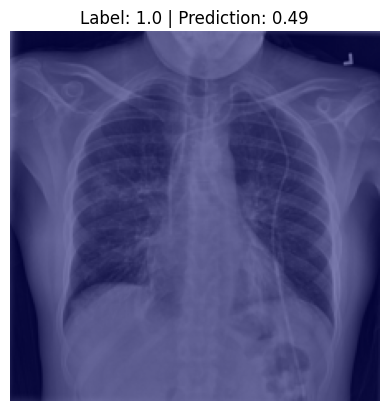

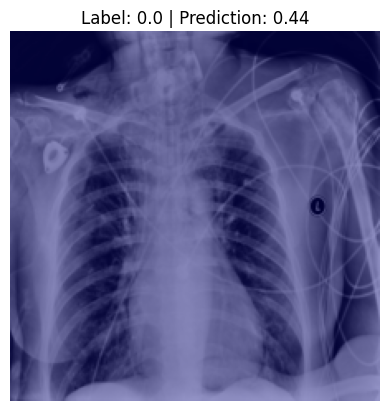

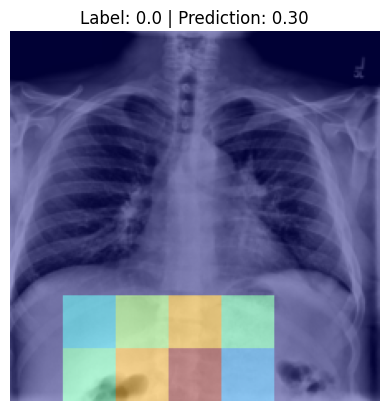

In [ ]:
def compute_occlusion(model, image, patch_size=32):
    model.eval()
    _, _, h, w = image.shape
    baseline_prediction = torch.sigmoid(model(image)).item()
    heatmap = np.zeros((h,w))
    for y in range(0, h, patch_size):
        for x in range(0, w, patch_size):
            occluded_image = image.clone()
            occluded_image[:,:,y:y+patch_size,x:x+patch_size] = 0

            occluded_prediction = torch.sigmoid(model(occluded_image)).item()

            heatmap[y:y+patch_size,x:x+patch_size] = baseline_prediction - occluded_prediction

    heatmap = np.maximum(heatmap,0)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)
    return heatmap
def display_occlusion(image_tensor, heatmap, label, prediction):
    image = image_tensor.numpy().transpose(1,2,0)
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    image = std * image + mean
    image = np.clip(image,0,1)
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap),cv2.COLORMAP_JET)
    heatmap_color = heatmap_color[...,::-1] / 255.0
    overlay = heatmap_color * 0.4 + image * 0.6
    overlay = np.clip(overlay,0,1)
    plt.imshow(overlay)
    plt.title(f"Label: {label} | Prediction: {prediction:.2f}")
    plt.axis("off")
    plt.show()
images, labels = next(iter(val_loader))
for i in range(4):
    image = images[i].unsqueeze(0).to(device)
    heatmap = compute_occlusion(model, image)
    prediction = torch.sigmoid(model(image)).item()
    display_occlusion(images[i], heatmap, labels[i].item(), prediction)

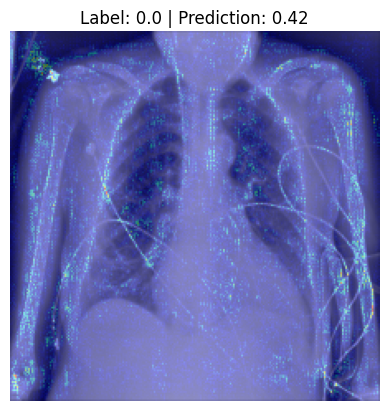

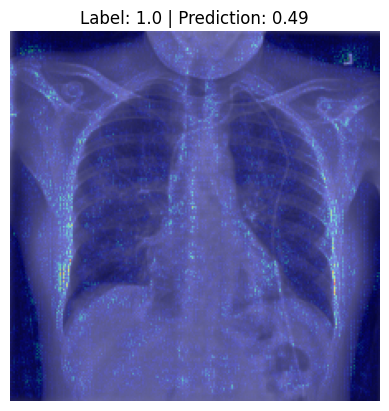

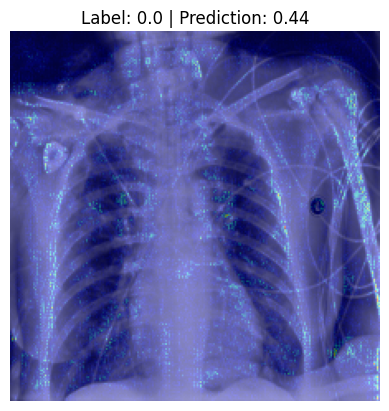

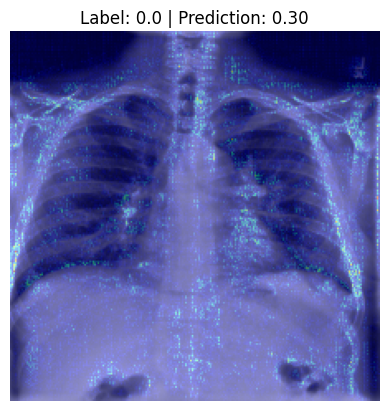

In [ ]:
integrated_gradients = IntegratedGradients(model)
def compute_integrated_gradients(model, image, baseline=None):
    model.eval()
    if baseline is None:
        baseline = torch.zeros_like(image).to(device)
    attributions = integrated_gradients.attribute(image,baselines=baseline,target=0)
    attribution_map = attributions.squeeze().cpu().detach().numpy()
    attribution_map = np.mean(np.abs(attribution_map),axis=0)
    attribution_map = (attribution_map - attribution_map.min()) / (attribution_map.max() + 1e-8)
    return attribution_map
def display_integrated_gradients(image_tensor,attribution_map,label,prediction):
    image = image_tensor.numpy().transpose(1,2,0)
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    image = std * image + mean
    image = np.clip(image,0,1)
    heatmap = cv2.applyColorMap(np.uint8(255 * attribution_map),cv2.COLORMAP_JET)
    heatmap = heatmap[...,::-1] / 255.0
    overlay = heatmap * 0.4 + image * 0.6
    overlay = np.clip(overlay,0,1)
    plt.imshow(overlay)
    plt.title(f"Label: {label} | Prediction: {prediction:.2f}")
    plt.axis("off")
    plt.show()
images, labels = next(iter(val_loader))
for i in range(4):
    image = images[i].unsqueeze(0).to(device)
    attribution_map = compute_integrated_gradients(model, image)
    prediction = torch.sigmoid(model(image)).item()
    display_integrated_gradients(images[i], attribution_map, labels[i].item(), prediction)